# South Australia Electricity Demand — Data, EDA, and Time-Series Diagnostics

## Role
This notebook characterises the half-hourly South Australia electricity-demand series
before any forecasting model is evaluated. Its purpose is to establish evidence for data
integrity, seasonal structure, persistence, distributional behaviour, demand extremes,
volatility/regime behaviour, evaluation-protocol design, and baseline/model-family
justification.

## Inputs
`data/electricity/australian_electricity_demand_dataset.tsf` (verified to exist below).

## Outputs
Descriptive and diagnostic evidence only: data-quality tables, descriptive statistics,
seasonality/autocorrelation evidence, stationarity-test results, and diagnostic figures.
No forecast artifact is written by this notebook.

## Depends On
None, other than the raw dataset and repository utilities.

## Authoritative Status
`AUTHORITATIVE ELECTRICITY DATA / EDA CHARACTERISATION`

## What This Notebook Does Not Do
This notebook does NOT:
- fit, select, or evaluate any forecasting model
- perform model selection or hyperparameter search
- compute a Trust Score
- perform statistical-significance testing
- perform any cross-domain comparison

## 1. Objective and Research Questions

> What temporal, seasonal, distributional, and structural properties of the South
> Australia half-hourly electricity-demand series must be accounted for when designing
> fair forecasting benchmarks and later trustworthiness diagnostics?

1. Is the selected series complete, chronological, and free of timestamp gaps?
2. How strong is short-range persistence?
3. Is there clear intraday seasonality?
4. Is there clear weekly seasonality?
5. Does demand variability change over time?
6. Are extreme high-demand and low-demand observations materially different from typical
   observations?
7. Is the level series stationary?
8. What do these findings imply for downstream models and evaluation protocols?

Downstream design decisions (baseline families, seasonal periods, evaluation protocols,
robustness regimes) should be evidence-driven rather than chosen only because particular
models happen to support them. This notebook does not itself prove forecastability: it
characterises the series so that later modelling and evaluation decisions have an
empirical basis. No forecasting model is trained or evaluated here.

## 2. Data Provenance and Dataset Metadata

Loading the raw file and locating it on disk first, so every provenance field below is
read from the artifact itself rather than asserted.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/")

ROOT = find_project_root(Path.cwd())
DATA_DIR = ROOT / "data" / "electricity"
TSF_PATH = DATA_DIR / "australian_electricity_demand_dataset.tsf"
assert TSF_PATH.exists(), f"Expected TSF file not found at {TSF_PATH}"


def load_tsf(path):
    metadata, attributes, rows = {}, [], []
    with Path(path).open(encoding="utf-8") as handle:
        for raw in handle:
            line = raw.strip()
            if not line or line.startswith("#"):
                continue
            if line.startswith("@attribute"):
                _, name, kind = line.split(maxsplit=2)
                attributes.append((name, kind))
            elif line.startswith("@") and not line.startswith("@data"):
                key, value = line[1:].split(maxsplit=1)
                metadata[key] = value
            elif not line.startswith("@"):
                parts = line.split(":", len(attributes))
                record = dict(zip((name for name, _ in attributes), parts[:-1]))
                record["series_value"] = np.fromstring(parts[-1], sep=",")
                rows.append(record)
    return pd.DataFrame(rows), metadata, attributes


series_df, tsf_metadata, tsf_attributes = load_tsf(TSF_PATH)

provenance = pd.DataFrame([
    {"Field": "Dataset", "Value": "Australian Electricity Demand"},
    {"Field": "Source file", "Value": TSF_PATH.name},
    {"Field": "Relation", "Value": tsf_metadata.get("relation", "Not documented in the local dataset artifact")},
    {"Field": "Frequency", "Value": tsf_metadata.get("frequency", "Not documented in the local dataset artifact")},
    {"Field": "Number of regional series", "Value": len(series_df)},
    {"Field": "Forecast horizon in TSF", "Value": tsf_metadata.get("forecast_horizon", "Not documented in the local dataset artifact")},
    {"Field": "Missing-value metadata", "Value": tsf_metadata.get("missing", "Not documented in the local dataset artifact")},
    {"Field": "Equal-length metadata", "Value": tsf_metadata.get("equallength", "Not documented in the local dataset artifact")},
    {"Field": "Declared attributes", "Value": ", ".join(name for name, _ in tsf_attributes) + ", series_value"},
    {"Field": "File size", "Value": f"{TSF_PATH.stat().st_size / 2**20:.3f} MiB"},
    {"Field": "Repository path", "Value": str(TSF_PATH.relative_to(ROOT))},
    {"Field": "Licence / collection method", "Value": "Not documented in the local dataset artifact"},
])
display(provenance)

,Field,Value
0,Dataset,Australian Electricity Demand
1,Source file,australian_electricity_demand_dataset.tsf
2,Relation,Aus_Electricity_Demand
3,Frequency,half_hourly
4,Number of regional series,5
5,Forecast horizon in TSF,Not documented in the local dataset artifact
6,Missing-value metadata,false
7,Equal-length metadata,false
8,Declared attributes,"series_name, state, start_timestamp, series_value"
9,File size,12.801 MiB


The local TSF artifact documents relation name, frequency, and per-series completeness
flags, but records no licence, source organisation, or collection-method metadata — those
fields are reported above as not documented rather than inferred. The five declared
attributes (`series_name`, `state`, `start_timestamp`, plus the raw `series_value` column)
are sufficient to identify and reconstruct each regional series unambiguously, which
Section 4 relies on.

## 3. Regional Series Inventory

Every regional series present in the TSF file, not only South Australia.

In [2]:
regional = series_df.copy()
regional["start_timestamp"] = pd.to_datetime(regional["start_timestamp"], format="%Y-%m-%d %H-%M-%S")
regional["series_length"] = regional["series_value"].map(len)
regional["end_timestamp"] = regional.apply(
    lambda r: r["start_timestamp"] + pd.Timedelta(minutes=30 * (r["series_length"] - 1)), axis=1)
regional["approx_years"] = regional["series_length"] / (48 * 365.2425)

inventory = regional[["series_name", "state", "start_timestamp", "end_timestamp", "series_length", "approx_years"]].rename(columns={
    "series_name": "Series Name", "state": "State", "start_timestamp": "Start Timestamp",
    "end_timestamp": "End Timestamp", "series_length": "Observations", "approx_years": "Approximate Years",
})
display(inventory.round({"Approximate Years": 2}))

,Series Name,State,Start Timestamp,End Timestamp,Observations,Approximate Years
0,T1,NSW,2002-01-01,2015-02-28 23:30:00,230736,13.16
1,T2,VIC,2002-01-01,2015-02-28 23:30:00,230736,13.16
2,T3,QUN,2002-01-01,2015-04-01 23:30:00,232272,13.25
3,T4,SA,2002-01-01,2015-03-01 23:30:00,230784,13.16
4,T5,TAS,2002-01-01,2015-02-28 23:30:00,230736,13.16


All five regional series (New South Wales, Victoria, Queensland, South Australia,
Tasmania) share the same half-hourly frequency and near-identical start dates, but their
lengths differ slightly (`equallength=false` in Section 2 is consistent with this) — end
dates range from late February to early April 2015. Each series is uniquely identified by
`state`, which Section 4 uses for selection.

## 4. South Australia Series Selection

South Australia is selected using the explicit `state` metadata rather than relying on
row order, so the selection remains correct even if the TSF file's row ordering ever
changes.

In [3]:
sa_match = regional[regional["state"].str.strip().str.casefold().isin(["sa", "south australia"])]
assert len(sa_match) == 1, "South Australia is not uniquely identifiable from state metadata."
sa_row = sa_match.iloc[0]

selection_table = pd.DataFrame([{
    "Property": "Series name", "Value": sa_row["series_name"],
}, {
    "Property": "State", "Value": sa_row["state"],
}, {
    "Property": "Start", "Value": sa_row["start_timestamp"],
}, {
    "Property": "End", "Value": sa_row["end_timestamp"],
}, {
    "Property": "Frequency", "Value": "30 minutes",
}, {
    "Property": "Observations", "Value": int(sa_row["series_length"]),
}, {
    "Property": "Approximate years", "Value": round(sa_row["approx_years"], 2),
}])
display(selection_table)

,Property,Value
0,Series name,T4
1,State,SA
2,Start,2002-01-01 00:00:00
3,End,2015-03-01 23:30:00
4,Frequency,30 minutes
5,Observations,230784
6,Approximate years,13.16


## 5. Canonical Series Construction

The canonical South Australia time index is reconstructed deterministically from the
declared start timestamp, the fixed 30-minute frequency, and the series length recorded
in the TSF file — the same reconstruction rule used by every downstream Electricity
notebook (`load_electricity_partitions` in `src/electricity_classical_models.py`). No
forecasting is performed here.

In [4]:
sa_index = pd.date_range(sa_row["start_timestamp"], periods=int(sa_row["series_length"]), freq="30min")
sa = pd.Series(sa_row["series_value"], index=sa_index, name="Demand", dtype=float)

assert sa.index.is_monotonic_increasing, "Canonical index is not chronologically ordered."
assert pd.infer_freq(sa.index) == "30min", "Canonical index frequency is not exactly 30 minutes."
assert len(sa) == int(sa_row["series_length"]), "Canonical series length does not match the declared TSF length."
print(f"Canonical series constructed: {len(sa):,} observations, {sa.index.min()} to {sa.index.max()}.")

Canonical series constructed: 230,784 observations, 2002-01-01 00:00:00 to 2015-03-01 23:30:00.


## 6. Data Quality and Temporal Integrity Audit

Repeated demand values are not treated as data-quality errors on their own — low-demand
half-hours during quiet overnight periods can legitimately repeat similar readings; only
the checks below (timestamp gaps, missingness, non-finite values, sign) are treated as
integrity issues.

In [5]:
expected_index = pd.date_range(sa.index.min(), sa.index.max(), freq="30min")
missing_ts = expected_index.difference(sa.index)

audit_rows = [
    ("Observations", len(sa), f"{len(sa):,} half-hourly observations"),
    ("Inferred frequency", pd.infer_freq(sa.index), "Matches the declared 30-minute cadence"),
    ("Monotonic ordering", bool(sa.index.is_monotonic_increasing), "Chronological, no reordering needed"),
    ("Duplicate timestamps", int(sa.index.duplicated().sum()), "0 expected for a clean half-hourly index"),
    ("Missing timestamps", int(len(missing_ts)), "0 expected; gaps would require explicit handling"),
    ("Missing demand values", int(sa.isna().sum()), "0 expected; NaNs would require explicit handling"),
    ("Non-finite values", int((~np.isfinite(sa)).sum()), "0 expected; inf/-inf would indicate a parsing error"),
    ("Zero demand values", int(sa.eq(0).sum()), "0 observed; a zero reading would be physically implausible for grid demand"),
    ("Negative demand values", int(sa.lt(0).sum()), "0 expected; negative demand would be physically implausible"),
    ("48 observations = one day", bool(sa.index[48] - sa.index[0] == pd.Timedelta(days=1)), "Confirms the half-hourly cadence over a full day"),
    ("336 observations = one week", bool(sa.index[336] - sa.index[0] == pd.Timedelta(days=7)), "Confirms the half-hourly cadence over a full week"),
]
quality_audit = pd.DataFrame(audit_rows, columns=["Check", "Result", "Interpretation"])
display(quality_audit)

if len(missing_ts) > 0:
    display(pd.Series(missing_ts, name="Missing Timestamp").to_frame())
else:
    print("No timestamp gaps were detected.")

,Check,Result,Interpretation
0,Observations,230784,"230,784 half-hourly observations"
1,Inferred frequency,30min,Matches the declared 30-minute cadence
2,Monotonic ordering,True,"Chronological, no reordering needed"
3,Duplicate timestamps,0,0 expected for a clean half-hourly index
4,Missing timestamps,0,0 expected; gaps would require explicit handling
5,Missing demand values,0,0 expected; NaNs would require explicit handling
6,Non-finite values,0,0 expected; inf/-inf would indicate a parsing ...
7,Zero demand values,0,0 observed; a zero reading would be physically...
8,Negative demand values,0,0 expected; negative demand would be physicall...
9,48 observations = one day,True,Confirms the half-hourly cadence over a full day


No timestamp gaps were detected.


## 7. Descriptive Statistics

Full descriptive profile of the demand level, computed directly from the canonical series
(no hard-coded values).

In [6]:
from scipy import stats

def describe_series(s):
    clean = s.dropna()
    q = clean.quantile([0.01, 0.05, 0.25, 0.75, 0.95, 0.99])
    return pd.Series({
        "N": int(clean.count()), "Mean": clean.mean(), "Median": clean.median(), "Std": clean.std(),
        "Min": clean.min(), "1%": q[0.01], "5%": q[0.05], "25%": q[0.25], "75%": q[0.75],
        "95%": q[0.95], "99%": q[0.99], "Max": clean.max(),
        "IQR": q[0.75] - q[0.25], "Coefficient of Variation": clean.std() / clean.mean(),
        "Skewness": stats.skew(clean), "Excess Kurtosis": stats.kurtosis(clean, fisher=True),
    })

descriptive_stats = describe_series(sa).to_frame("Demand").round(4)
display(descriptive_stats)

,Demand
N,230784.0000
Mean,1290.5922
Median,1271.5761
Std,301.1220
Min,488.8354
1%,799.7712
5%,877.6125
25%,1063.4939
75%,1459.6081
95%,1811.7895


Central tendency and dispersion are moderate relative to their own scale (mean
approximately 1,291, median approximately 1,272, std approximately 301, coefficient of
variation approximately 0.23) — mean and median are reasonably close, so the level
distribution is not dominated by a small number of extreme values. Skewness is positive
and moderate (approximately 0.94), indicating a right-skewed distribution: demand spends
more time at or below the median than above it, with a longer tail toward unusually high
readings. Excess kurtosis is positive (approximately 1.97), so the distribution is
moderately heavier-tailed than a normal reference, consistent with the high-demand
extremes examined in Section 13. No causal explanation is implied by any of these
figures — they describe the observed distribution only.

## 8. Temporal Coverage and Evaluation Context

**FROZEN DOWNSTREAM EVALUATION PARTITIONS — DISPLAYED HERE FOR CONTEXT ONLY.** The
Development / Validation / Pre-test / Test boundaries below are loaded read-only from
`load_electricity_partitions` (`src/electricity_classical_models.py`), the same utility
every downstream Electricity notebook (11-18) uses — they are not recomputed, redefined,
or altered here. All later training, hyperparameter selection, calibration, and
robustness-threshold construction must respect these chronological boundaries.

In [7]:
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.electricity_classical_models import load_electricity_partitions

parts = load_electricity_partitions(ROOT)
partition_table = pd.DataFrame([
    {"Partition": "Development", "Start": parts.development.index.min(), "End": parts.development.index.max(),
     "Observations": len(parts.development), "Days": len(parts.development) / 48},
    {"Partition": "Validation", "Start": parts.validation.index.min(), "End": parts.validation.index.max(),
     "Observations": len(parts.validation), "Days": len(parts.validation) / 48},
    {"Partition": "Pre-test (Development + Validation)", "Start": parts.pretest.index.min(), "End": parts.pretest.index.max(),
     "Observations": len(parts.pretest), "Days": len(parts.pretest) / 48},
    {"Partition": "Test", "Start": parts.test.index.min(), "End": parts.test.index.max(),
     "Observations": len(parts.test), "Days": len(parts.test) / 48},
])
display(partition_table)

assert parts.full.equals(sa), "Partition utility's full series does not match this notebook's canonical series."

E:\Re_Sc_AM\TimeSeriesFoundationModels\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


,Partition,Start,End,Observations,Days
0,Development,2002-01-01,2011-06-23 23:30:00,166128,3461.0
1,Validation,2011-06-24,2012-07-12 23:30:00,18480,385.0
2,Pre-test (Development + Validation),2002-01-01,2012-07-12 23:30:00,184608,3846.0
3,Test,2012-07-13,2015-03-01 23:30:00,46176,962.0


Pre-test (Development plus Validation, 2002-01-01 to 2012-07-12) is used for final model
fitting once hyperparameters are selected on Validation alone; Test (2012-07-13 to
2015-03-01, 46,176 observations / 962 days) is the frozen final evaluation window used by
every model comparison, robustness check, and significance test in notebooks 11-18. This
notebook's own full-series descriptive analysis (Sections 7-16 below) is not the same
thing as this evaluation context — see Section 18 for the distinction.

## 9. Raw Demand Series

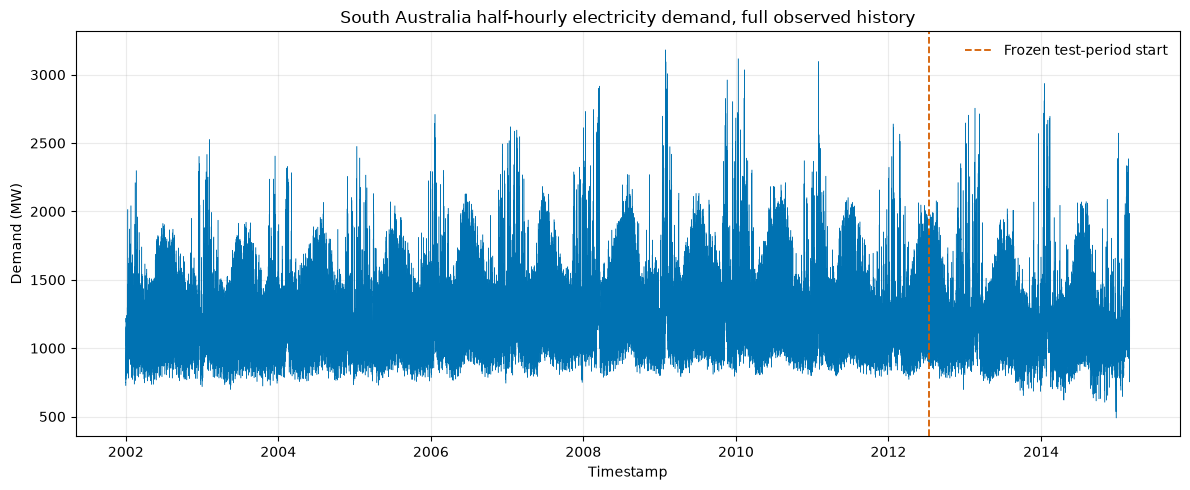

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sa.index, sa, color="#0072B2", linewidth=0.35)
ax.axvline(parts.test.index.min(), color="#D55E00", linestyle="--", linewidth=1.3, label="Frozen test-period start")
ax.set(title="South Australia half-hourly electricity demand, full observed history", xlabel="Timestamp", ylabel="Demand (MW)")
ax.grid(alpha=0.25); ax.legend(frameon=False)
fig.tight_layout(); from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "electricity"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "electricity_demand_history.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

The full 13-year history shows a persistent, large-amplitude repeating cycle (visible even
at this compressed scale) rather than a single dominant long-run trend, with variable
amplitude across years and a small number of visibly extreme upward excursions (examined
further in Section 13). The dashed line marks where the frozen test period (Section 8)
begins; no structural-break date is claimed from this plot alone.

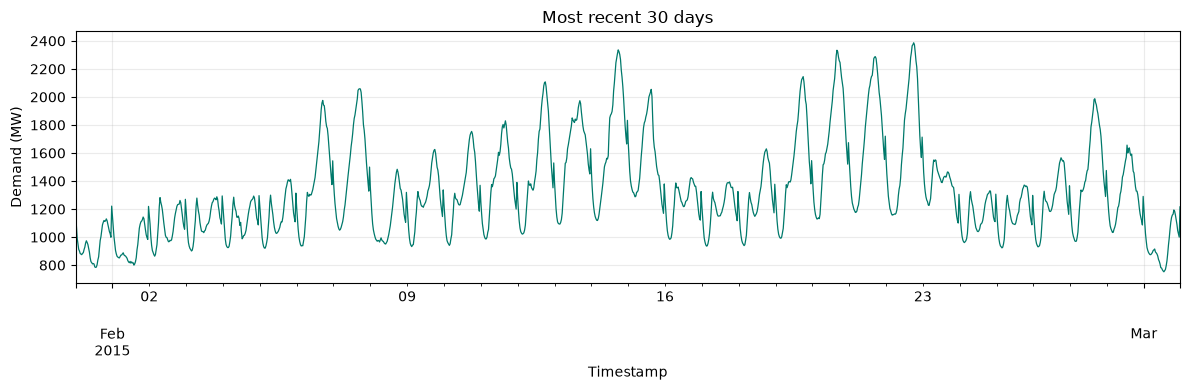

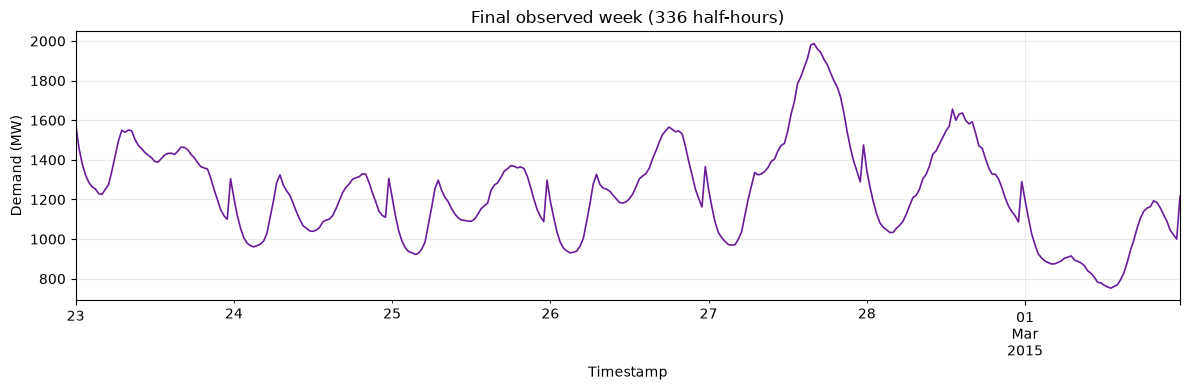

In [9]:
recent = sa.iloc[-48 * 30:]
ax = recent.plot(figsize=(12, 4), lw=0.9, color="#00796b", title="Most recent 30 days")
ax.set(xlabel="Timestamp", ylabel="Demand (MW)"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

week = sa.iloc[-336:]
ax = week.plot(figsize=(12, 4), lw=1.2, color="#6a1b9a", title="Final observed week (336 half-hours)")
ax.set(xlabel="Timestamp", ylabel="Demand (MW)"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

At the 30-day scale, the repeating daily cycle is unmistakable; at the one-week scale, a
weekday/weekend amplitude difference is already visible by eye, motivating the formal
weekly analysis in Section 11.

## 10. Intraday Demand Structure

### 10.1 Mean Intraday Profile

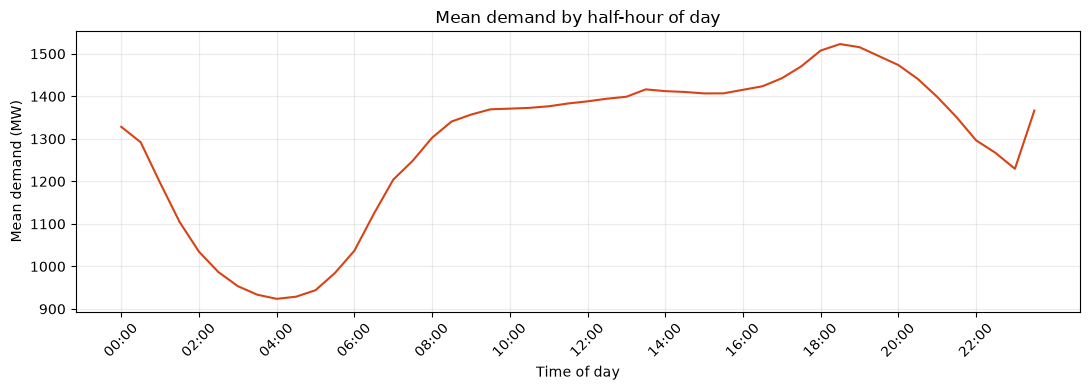

In [10]:
tod = sa.groupby(sa.index.strftime("%H:%M")).mean()
ax = tod.plot(figsize=(11, 4), color="#d84315", title="Mean demand by half-hour of day")
ax.set(xlabel="Time of day", ylabel="Mean demand (MW)")
ax.set_xticks(range(0, 48, 4)); ax.set_xticklabels(tod.index[::4], rotation=45)
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

### 10.2 Intraday Profile Table

Key positions from the full 48-slot profile: overall trough, overall peak, and the
morning/evening shoulders around them.

In [11]:
intraday_profile = sa.groupby(sa.index.strftime("%H:%M")).agg(["mean", "median", "std", lambda s: s.quantile(.05), lambda s: s.quantile(.95)])
intraday_profile.columns = ["Mean", "Median", "Std", "5th Percentile", "95th Percentile"]
intraday_profile.index.name = "Half-Hour"

trough_slot = intraday_profile["Mean"].idxmin()
peak_slot = intraday_profile["Mean"].idxmax()
key_slots = sorted(set([trough_slot, peak_slot, "07:00", "07:30", "17:00", "17:30"]) & set(intraday_profile.index))
display(intraday_profile.loc[key_slots].round(2))
print(f"Intraday trough: {trough_slot} (mean {intraday_profile.loc[trough_slot,'Mean']:.1f}); "
      f"intraday peak: {peak_slot} (mean {intraday_profile.loc[peak_slot,'Mean']:.1f}).")

,Mean,Median,Std,5th Percentile,95th Percentile
Half-Hour,,,,,
04:00,923.74,913.58,90.39,805.70,1064.18
07:00,1204.04,1228.75,211.71,850.98,1504.73
07:30,1248.33,1286.66,229.99,860.13,1587.45
17:00,1442.49,1399.56,308.64,1041.89,2058.79
17:30,1470.42,1418.47,300.02,1067.88,2020.55
18:30,1522.92,1474.49,303.61,1105.83,2045.48


Intraday trough: 04:00 (mean 923.7); intraday peak: 18:30 (mean 1522.9).


### 10.3 Intraday Variability Visualization

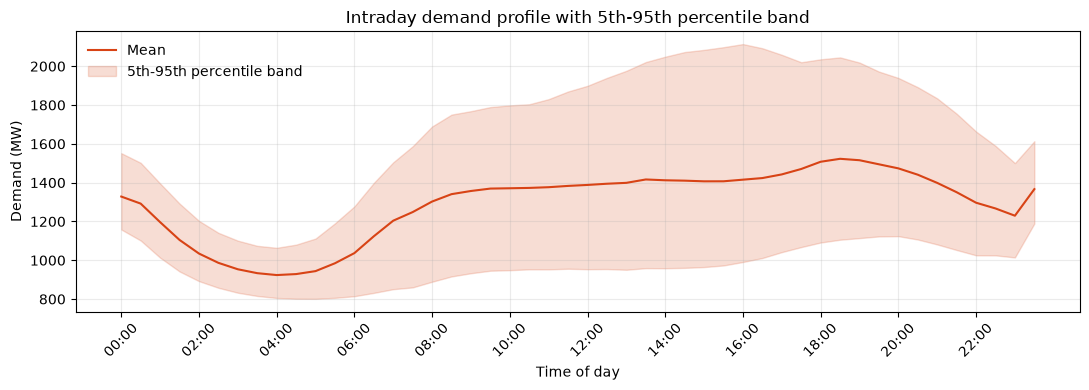

In [12]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(48), intraday_profile["Mean"].to_numpy(), color="#d84315", label="Mean")
ax.fill_between(range(48), intraday_profile["5th Percentile"].to_numpy(), intraday_profile["95th Percentile"].to_numpy(),
                 color="#d84315", alpha=0.18, label="5th-95th percentile band")
ax.set(title="Intraday demand profile with 5th-95th percentile band", xlabel="Time of day", ylabel="Demand (MW)")
ax.set_xticks(range(0, 48, 4)); ax.set_xticklabels(intraday_profile.index[::4], rotation=45)
ax.grid(alpha=0.25); ax.legend(frameon=False)
plt.tight_layout(); from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "electricity"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "electricity_intraday_profile.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

The intraday trough sits in the early hours of the morning and the peak in the early
evening, consistent with typical residential/commercial demand cycles. The percentile band
is visibly narrower overnight (low demand is fairly consistent night-to-night) and wider
around the evening peak (peak-hour demand varies more from day to day than trough-hour
demand does) — this amplitude-dependent variability motivates the volatility analysis in
Section 14.

## 11. Weekly Demand Structure

### 11.1 Weekday Summary Table

In [13]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_stats = sa.groupby(sa.index.day_name()).agg(["mean", "median", "std", "count"]).reindex(weekday_order)
weekday_stats.columns = ["Mean", "Median", "Std", "N"]
display(weekday_stats.round(2))

,Mean,Median,Std,N
Monday,1320.60,1318.34,305.56,32928
Tuesday,1359.54,1358.15,299.86,32976
Wednesday,1361.12,1363.52,292.31,32976
Thursday,1366.81,1365.71,299.62,32976
Friday,1337.77,1332.89,290.88,32976
Saturday,1171.99,1133.48,252.52,32976
Sunday,1116.36,1076.84,254.52,32976


### 11.2 Weekday Visualization

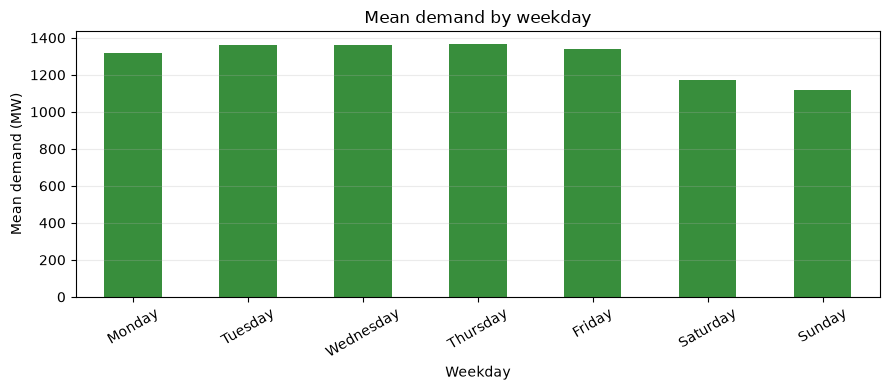

In [14]:
ax = weekday_stats["Mean"].plot(kind="bar", figsize=(9, 4), color="#388e3c", title="Mean demand by weekday")
ax.set(xlabel="Weekday", ylabel="Mean demand (MW)"); ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

### 11.3 Weekday x Time-of-Day Heatmap

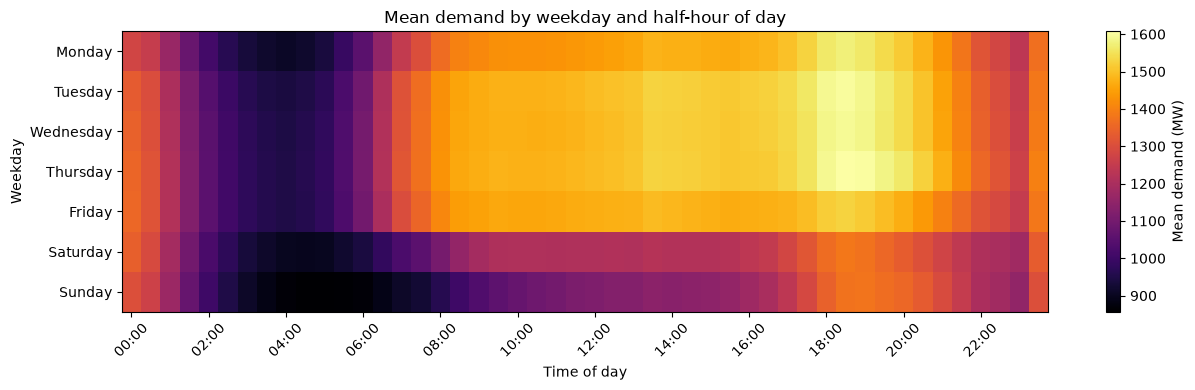

In [15]:
heat = sa.groupby([sa.index.day_name(), sa.index.strftime("%H:%M")]).mean().unstack().reindex(weekday_order)
fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(heat.to_numpy(), aspect="auto", cmap="inferno")
ax.set_yticks(range(len(weekday_order))); ax.set_yticklabels(weekday_order)
ax.set_xticks(range(0, 48, 4)); ax.set_xticklabels(heat.columns[::4], rotation=45)
ax.set(title="Mean demand by weekday and half-hour of day", xlabel="Time of day", ylabel="Weekday")
fig.colorbar(im, ax=ax, label="Mean demand (MW)")
plt.tight_layout(); from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "electricity"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "electricity_weekday_intraday_heatmap.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

Weekdays (Monday-Friday) show a consistently higher and more sharply peaked profile than
the weekend, and the weekend's evening ramp is both lower and flatter, consistent with
reduced commercial/industrial load. The heatmap shows this weekday/weekend contrast holds
across nearly every half-hour of the day rather than being concentrated in one narrow
window — intraday and weekly seasonality are both persistent and largely independent
sources of structure, which is why later notebooks (Section 17) treat them as two
seasonal periods (48 and 336) rather than folding one into the other.

## 12. Seasonal Dependence and Autocorrelation

### 12.1 Selected-Lag Table

,lag_half_hours,autocorrelation,interpretation
0,1,0.984394,30 minutes
1,2,0.949438,1 hour
2,48,0.807537,1 day
3,96,0.612894,2 days
4,336,0.699652,1 week
5,672,0.663855,2 weeks


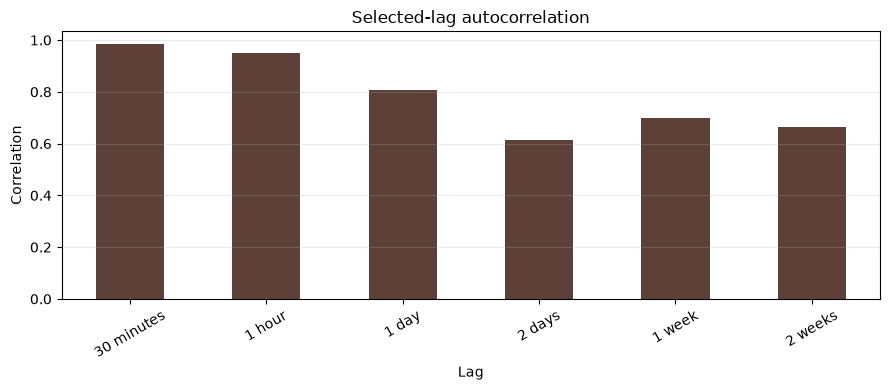

In [16]:
lags = [1, 2, 48, 96, 336, 672]
lag_labels = ["30 minutes", "1 hour", "1 day", "2 days", "1 week", "2 weeks"]
lag_table = pd.DataFrame({"lag_half_hours": lags, "autocorrelation": [sa.autocorr(k) for k in lags], "interpretation": lag_labels})
display(lag_table)
ax = lag_table.plot.bar(x="interpretation", y="autocorrelation", legend=False, figsize=(9, 4), color="#5d4037")
ax.set(title="Selected-lag autocorrelation", xlabel="Lag", ylabel="Correlation"); ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

### 12.2 ACF Plot

Plotted over 400 lags (a little over one week) to keep lags 48, 96, and 336 all visible
without producing an unreadable wall of bars.

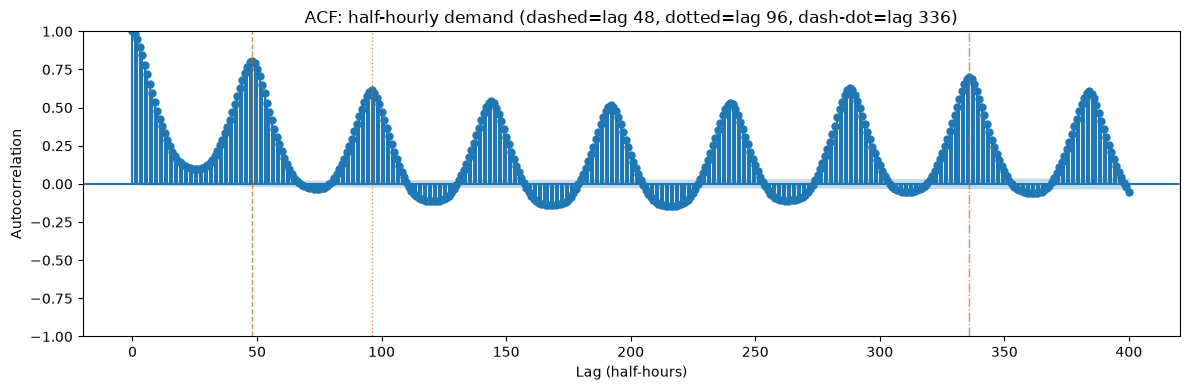

In [17]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(sa.to_numpy(), lags=400, ax=ax, alpha=0.05)
for lag, style in [(48, "--"), (96, ":"), (336, "-.")]:
    ax.axvline(lag, color="#D55E00", linestyle=style, linewidth=1, alpha=0.7)
ax.set(title="ACF: half-hourly demand (dashed=lag 48, dotted=lag 96, dash-dot=lag 336)", xlabel="Lag (half-hours)", ylabel="Autocorrelation")
plt.tight_layout(); plt.show()

### 12.3 Seasonal Lag Evidence

In [18]:
seasonal_lag_evidence = pd.DataFrame([
    {"Seasonal Scale": "30 min persistence", "Lag": 1, "ACF": sa.autocorr(1)},
    {"Seasonal Scale": "Daily", "Lag": 48, "ACF": sa.autocorr(48)},
    {"Seasonal Scale": "2-day", "Lag": 96, "ACF": sa.autocorr(96)},
    {"Seasonal Scale": "Weekly", "Lag": 336, "ACF": sa.autocorr(336)},
    {"Seasonal Scale": "2-week", "Lag": 672, "ACF": sa.autocorr(672)},
])
display(seasonal_lag_evidence.round(4))

,Seasonal Scale,Lag,ACF
0,30 min persistence,1,0.9844
1,Daily,48,0.8075
2,2-day,96,0.6129
3,Weekly,336,0.6997
4,2-week,672,0.6639


Lag-1 autocorrelation is very high (approximately 0.98), so short-range persistence is
strong — this is the empirical basis for evaluating a Naive (persistence) baseline. Lag-48
autocorrelation is also high (approximately 0.81), directly motivating a Daily Seasonal
Naive baseline and daily Fourier terms in DHR/Prophet. Lag-336 autocorrelation
(approximately 0.70) exceeds lag-96 (approximately 0.61), indicating the weekly cycle
reasserts itself more strongly than a simple 2-day-ahead echo would — this motivates a
Weekly Seasonal Naive baseline and weekly Fourier terms in DHR/Prophet, in clear contrast
to the Bitcoin daily series, where lag-7 dependence was found to be statistically
indistinguishable from zero. No claim about eventual forecasting-model accuracy is made
here; this section only establishes which seasonal structures are present to justify
which baseline families are evaluated later.

## 13. Distribution and Demand Extremes

### 13.1 Demand Histogram

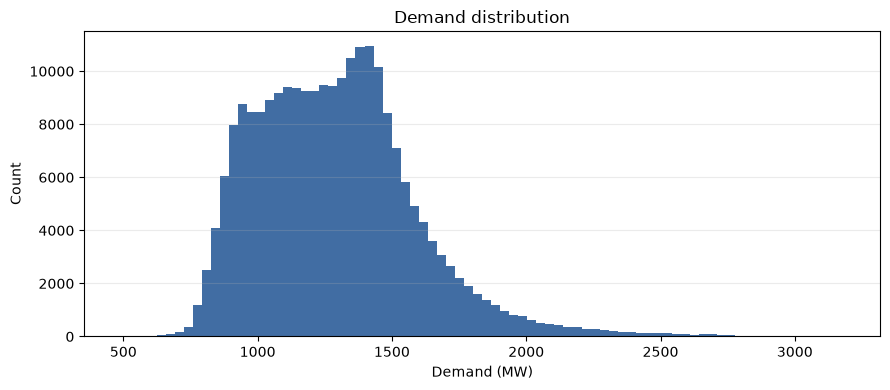

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sa, bins=80, color="#205493", alpha=0.85)
ax.set(title="Demand distribution", xlabel="Demand (MW)", ylabel="Count"); ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

### 13.2 Boxplot

C:\Users\HP\AppData\Local\Temp\ipykernel_11504\3869437957.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(sa, vert=True, widths=0.5, patch_artist=True,


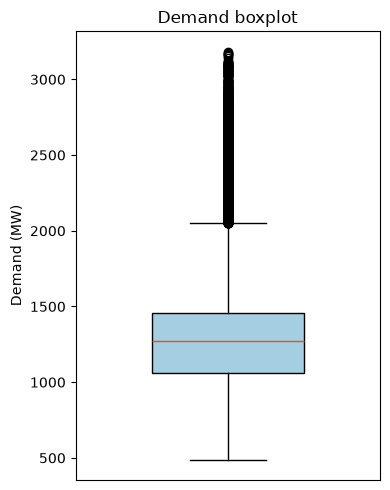

In [20]:
fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(sa, vert=True, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor="#a6cee3"), medianprops=dict(color="#D55E00"))
ax.set(title="Demand boxplot", ylabel="Demand (MW)", xticks=[])
plt.tight_layout(); plt.show()

### 13.3 Quantile Table

In [21]:
quantile_table = sa.quantile([.01, .05, .25, .5, .75, .95, .99]).to_frame("Demand")
display(quantile_table.round(2))

,Demand
0.01,799.77
0.05,877.61
0.25,1063.49
0.50,1271.58
0.75,1459.61
0.95,1811.79
0.99,2232.51


### 13.4 Extreme Observation Table

Reported as extreme observed demand, not "outliers" — no outlier-detection rule (e.g. IQR
or z-score threshold) is applied here.

In [22]:
def extremes_table(series, n, label):
    picked = series.nlargest(n) if label == "Highest" else series.nsmallest(n)
    out = picked.rename("Demand").to_frame()
    out["Weekday"] = out.index.day_name()
    out["Time of Day"] = out.index.strftime("%H:%M")
    out.index.name = "Timestamp"
    return out

print("10 highest observed demand values:")
display(extremes_table(sa, 10, "Highest"))
print("10 lowest observed demand values:")
display(extremes_table(sa, 10, "Lowest"))

10 highest observed demand values:


,Demand,Weekday,Time of Day
Timestamp,,,
2009-01-29 16:00:00,3182.476646,Thursday,16:00
2009-01-29 13:30:00,3171.980654,Thursday,13:30
2009-01-29 15:30:00,3168.398232,Thursday,15:30
2009-01-29 16:30:00,3168.079536,Thursday,16:30
2009-01-29 13:00:00,3162.350392,Thursday,13:00
2009-01-29 17:00:00,3153.684330,Thursday,17:00
2009-01-29 12:30:00,3142.421778,Thursday,12:30
2009-01-29 15:00:00,3120.763486,Thursday,15:00
2010-01-11 12:30:00,3117.644614,Monday,12:30


10 lowest observed demand values:


,Demand,Weekday,Time of Day
Timestamp,,,
2014-12-26 13:00:00,488.835380,Friday,13:00
2014-12-26 13:30:00,497.608498,Friday,13:30
2014-12-26 12:30:00,498.233186,Friday,12:30
2014-12-26 14:00:00,504.061744,Friday,14:00
2014-12-26 12:00:00,515.912776,Friday,12:00
2014-12-26 14:30:00,525.592354,Friday,14:30
2014-12-25 13:30:00,535.274702,Thursday,13:30
2014-12-26 11:30:00,538.560566,Friday,11:30
2014-12-25 14:00:00,548.155510,Thursday,14:00


The highest observed demand values cluster on a small number of specific dates (visible by
the repeated dates above) rather than being spread evenly across the 13-year history,
consistent with heat-wave-driven peak-demand events. The lowest observed values are not
overnight readings as the typical intraday trough (Section 10) might suggest — they
cluster around midday (approximately 11:30-14:30) on 2014-12-25 and 2014-12-26 (Christmas
Day and Boxing Day), when commercial and industrial demand appears to have collapsed on a
public holiday despite it being daytime. This is a useful reminder that the *typical*
intraday trough (overnight, on an average day) and the single *most extreme* low-demand
readings (a midday public holiday) are different questions — no causal explanation beyond
the calendar coincidence is asserted here.

## 14. Demand Variability and Structural Change

This section is a preview and motivation for later Regime-Conditional Robustness
analysis; it defines no final threshold and is purely descriptive of the full series.

### 14.1 First-Difference Plot

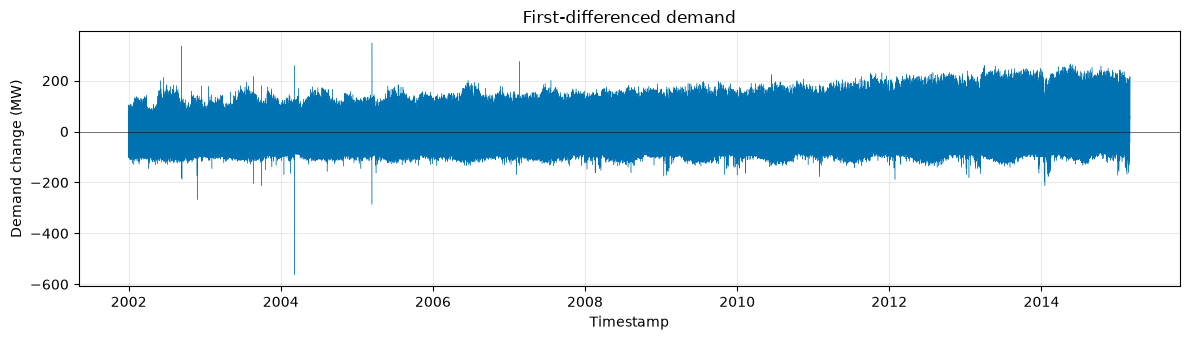

In [23]:
demand_diff = sa.diff().dropna()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(demand_diff.index, demand_diff, color="#0072B2", linewidth=0.3)
ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)
ax.set(title="First-differenced demand", xlabel="Timestamp", ylabel="Demand change (MW)")
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

### 14.2 Rolling Variability

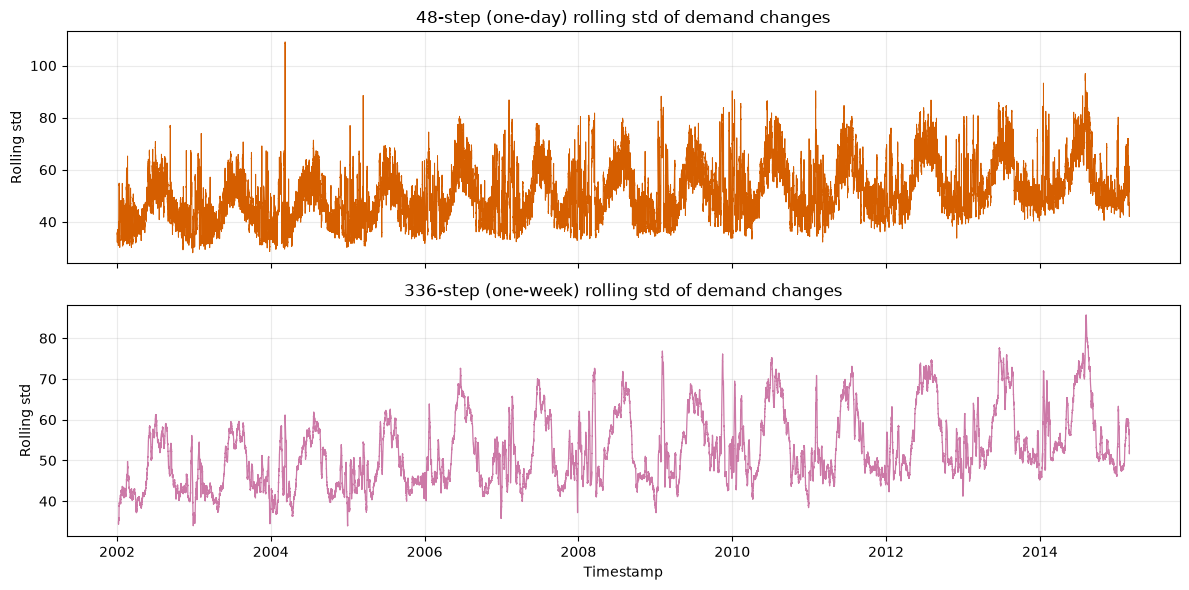

In [24]:
rolling_std_48 = demand_diff.rolling(48).std()
rolling_std_336 = demand_diff.rolling(336).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(rolling_std_48.index, rolling_std_48, color="#D55E00", linewidth=0.7)
axes[0].set(title="48-step (one-day) rolling std of demand changes", ylabel="Rolling std")
axes[1].plot(rolling_std_336.index, rolling_std_336, color="#CC79A7", linewidth=0.9)
axes[1].set(title="336-step (one-week) rolling std of demand changes", xlabel="Timestamp", ylabel="Rolling std")
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout(); from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "electricity"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "electricity_rolling_variability.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

### 14.3 Rolling Mean / Variance (Longer Window)

A one-month (`48*30`) window, longer than Section 14.2's daily/weekly windows, to reveal
slower-moving structure.

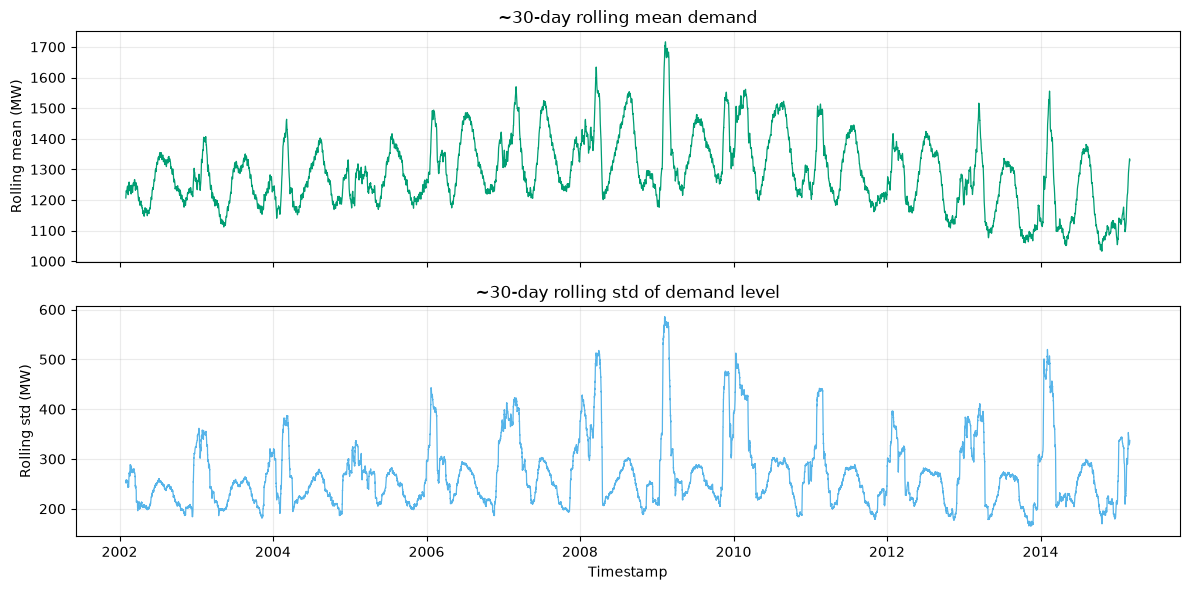

In [25]:
monthly_window = 48 * 30
rolling_mean_month = sa.rolling(monthly_window).mean()
rolling_std_month = sa.rolling(monthly_window).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(rolling_mean_month.index, rolling_mean_month, color="#009E73", linewidth=0.9)
axes[0].set(title="~30-day rolling mean demand", ylabel="Rolling mean (MW)")
axes[1].plot(rolling_std_month.index, rolling_std_month, color="#56B4E9", linewidth=0.9)
axes[1].set(title="~30-day rolling std of demand level", xlabel="Timestamp", ylabel="Rolling std (MW)")
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()

Both local (48-step) and weekly (336-step) rolling variability of demand changes fluctuate
over time rather than sitting at a constant level, with visible episodes of elevated
variability that do not obviously align to a single calendar pattern. The 30-day rolling
mean shows a clear repeating seasonal (summer/winter) rise and fall in addition to any
slower multi-year drift, and the 30-day rolling std shows corresponding swings in
variability. This is presented as visual motivation only — no volatility-regime threshold
is defined in this notebook; regime thresholds are defined later from training/pre-test
data only (Section 16, Section 18).

## 15. Stationarity and Differencing Diagnostics

Two complementary tests are applied to the raw demand level, the first difference, and
seasonal differences at lag 48 (daily) and lag 336 (weekly):

- **Augmented Dickey-Fuller (ADF)**: H0 = the series has a unit root (is non-stationary).
  Rejecting H0 supports stationarity.
- **KPSS**: H0 = the series is stationary around the specified deterministic component.
  Rejecting H0 supports non-stationarity.

Both use a constant-only deterministic specification (`regression="c"`). ADF uses a fixed
lag order of 48 (matching the daily seasonal period already established in Sections 10-12)
rather than automatic AIC-based lag selection, which is computationally prohibitive at
this sample size (more than 200,000 observations, versus a few thousand for the Bitcoin
daily series) — the fixed lag is a computational choice, not tuned for significance.

In [26]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

def adf_row(series, label):
    stat, pvalue, *_ = adfuller(series.dropna().to_numpy(), regression="c", autolag=None, maxlag=48)
    return {"Series": label, "ADF Statistic": stat, "ADF p": pvalue}

def kpss_row(series, label):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, pvalue, *_ = kpss(series.dropna().to_numpy(), regression="c", nlags="auto")
    return {"KPSS Statistic": stat, "KPSS p": pvalue}

seasonal_diff_48 = sa.diff(48).dropna()
seasonal_diff_336 = sa.diff(336).dropna()

stationarity_rows = []
for series, label in [(sa, "Raw demand level"), (demand_diff, "First difference"),
                       (seasonal_diff_48, "Seasonal difference (lag 48)"), (seasonal_diff_336, "Seasonal difference (lag 336)")]:
    row = {**adf_row(series, label), **kpss_row(series, label)}
    row["Interpretation"] = ("ADF/KPSS agree: stationary" if row["ADF p"] < 0.05 and row["KPSS p"] >= 0.05
                              else "ADF/KPSS agree: non-stationary" if row["ADF p"] >= 0.05 and row["KPSS p"] < 0.05
                              else "ADF/KPSS disagree")
    stationarity_rows.append(row)

stationarity_results = pd.DataFrame(stationarity_rows, columns=["Series", "ADF Statistic", "ADF p", "KPSS Statistic", "KPSS p", "Interpretation"])
display(stationarity_results.round(6))

,Series,ADF Statistic,ADF p,KPSS Statistic,KPSS p,Interpretation
0,Raw demand level,-69.765852,0.0,4.188789,0.01,ADF/KPSS disagree
1,First difference,-65.943659,0.0,0.000929,0.10,ADF/KPSS agree: stationary
2,Seasonal difference (lag 48),-43.429537,0.0,0.003588,0.10,ADF/KPSS agree: stationary
3,Seasonal difference (lag 336),-38.984275,0.0,0.004418,0.10,ADF/KPSS agree: stationary


Interpretation should not be reduced to a single p-value: ADF's null is a unit root
(rejecting supports stationarity), while KPSS's null is stationarity itself (rejecting
supports non-stationarity) — these are not mirror-image tests of the same hypothesis, and
each is more sensitive to different departures (ADF to unit-root-like persistence, KPSS to
slow drift or unmodelled deterministic structure such as remaining seasonality).
Differencing and seasonal structure are both empirically motivated here as evidence for
why later statistical models (ARIMA's non-seasonal differencing, DHR's explicit
seasonal-Fourier design, SARIMA's seasonal order) are constructed the way they are — this
notebook does not itself select or alter any downstream ARIMA/SARIMA order, which is
frozen in `11_Electricity_Classical_Baselines.ipynb`.

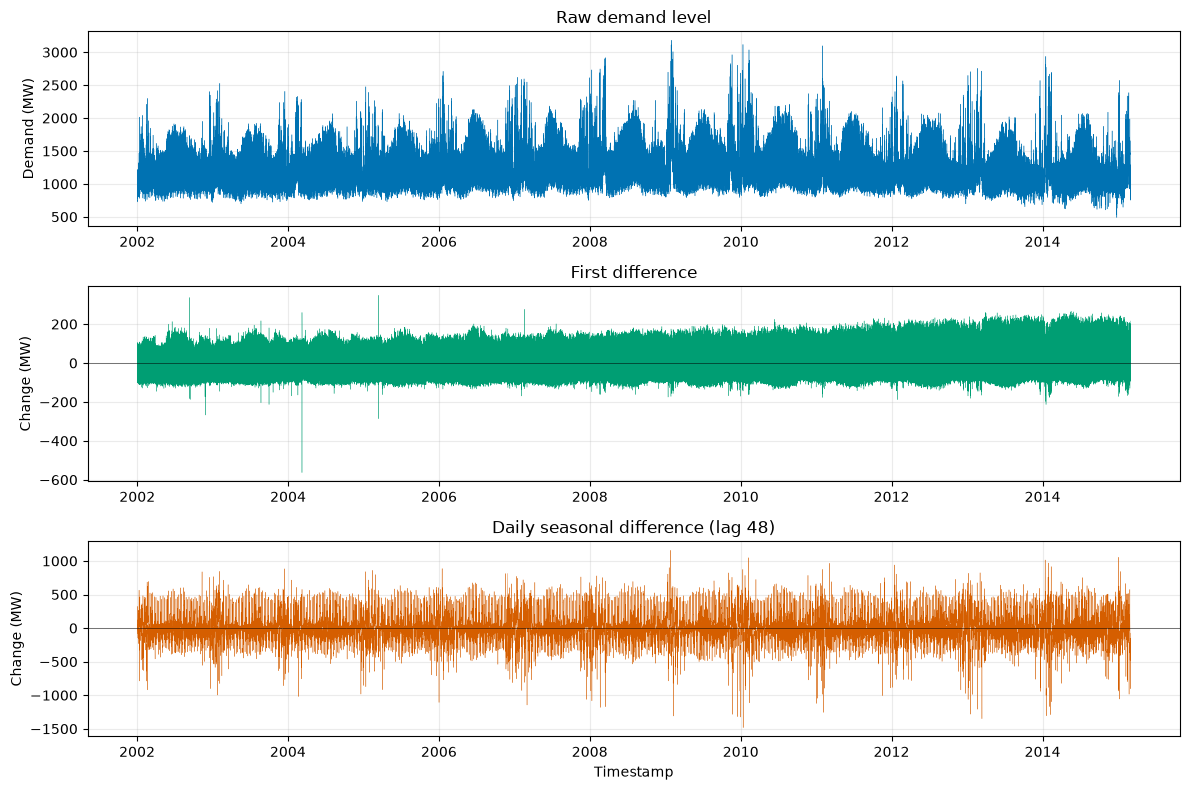

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
axes[0].plot(sa.index, sa, color="#0072B2", linewidth=0.3); axes[0].set(title="Raw demand level", ylabel="Demand (MW)")
axes[1].plot(demand_diff.index, demand_diff, color="#009E73", linewidth=0.25); axes[1].axhline(0, color="black", linewidth=0.6, alpha=0.6)
axes[1].set(title="First difference", ylabel="Change (MW)")
axes[2].plot(seasonal_diff_48.index, seasonal_diff_48, color="#D55E00", linewidth=0.25); axes[2].axhline(0, color="black", linewidth=0.6, alpha=0.6)
axes[2].set(title="Daily seasonal difference (lag 48)", xlabel="Timestamp", ylabel="Change (MW)")
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()

## 16. Peak and Low Demand Event Characterisation

**DESCRIPTIVE EDA THRESHOLDS** below are simple full-series percentile cuts, computed
transparently in this section for descriptive purposes only. They are a **different,
independent definition** from the **FROZEN ROBUSTNESS THRESHOLDS** used in
`15_Electricity_Robustness.ipynb`, which are derived from pre-test/training-only data
under that notebook's own methodology and are not recomputed, asserted equal, or altered
here.

In [28]:
low_cut, high_cut, peak_cut = sa.quantile([.10, .90, .99])
event_table = pd.DataFrame([
    {"Event Type": "Low demand", "Definition": "Below 10th percentile (descriptive EDA threshold)", "Threshold": low_cut,
     "Observations": int((sa < low_cut).sum()), "Share": (sa < low_cut).mean()},
    {"Event Type": "High demand", "Definition": "Above 90th percentile (descriptive EDA threshold)", "Threshold": high_cut,
     "Observations": int((sa > high_cut).sum()), "Share": (sa > high_cut).mean()},
    {"Event Type": "Peak demand event", "Definition": "Above 99th percentile (descriptive EDA threshold)", "Threshold": peak_cut,
     "Observations": int((sa > peak_cut).sum()), "Share": (sa > peak_cut).mean()},
])
display(event_table.round(4))

,Event Type,Definition,Threshold,Observations,Share
0,Low demand,Below 10th percentile (descriptive EDA threshold),928.8842,23079,0.10
1,High demand,Above 90th percentile (descriptive EDA threshold),1655.5929,23079,0.10
2,Peak demand event,Above 99th percentile (descriptive EDA threshold),2232.5109,2308,0.01


In [29]:
def composition(mask, label):
    subset = sa[mask]
    return {"Event": label, "Most Common Weekday": subset.index.day_name().value_counts().idxmax(),
            "Most Common Half-Hour": subset.index.strftime("%H:%M").value_counts().idxmax(), "N": int(mask.sum())}

composition_table = pd.DataFrame([
    composition(sa > high_cut, "High demand"),
    composition(sa > peak_cut, "Peak demand event"),
    composition(sa < low_cut, "Low demand"),
])
display(composition_table)

,Event,Most Common Weekday,Most Common Half-Hour,N
0,High demand,Thursday,18:30,23079
1,Peak demand event,Tuesday,16:00,2308
2,Low demand,Sunday,04:00,23079


High-demand and peak-demand-event half-hours are concentrated on weekdays and in the
evening peak window identified in Section 10, while low-demand half-hours concentrate
overnight — consistent with, but not identical to, the frozen regime definitions used
downstream. This section characterises what "unusual" demand looks like descriptively; it
does not define or override the authoritative robustness regimes.

## 17. Forecastability and Benchmark Implications

Synthesising the EDA evidence above into explicit methodological consequences.

In [30]:
implications = pd.DataFrame([
    {"EDA Finding": "Very strong lag-1 persistence (ACF ~0.98, Section 12)", "Forecasting Implication": "A persistence benchmark is required",
     "Downstream Use": "Naive"},
    {"EDA Finding": "Strong lag-48 recurrence (ACF ~0.81, Section 12)", "Forecasting Implication": "A daily seasonal benchmark is required",
     "Downstream Use": "Daily Seasonal Naive"},
    {"EDA Finding": "Lag-336 recurrence exceeds lag-96 (Section 12)", "Forecasting Implication": "A weekly seasonal benchmark is required",
     "Downstream Use": "Weekly Seasonal Naive / weekly Fourier terms"},
    {"EDA Finding": "Simultaneous daily and weekly structure (Sections 10-12)", "Forecasting Implication": "Model families should accommodate more than one seasonal period",
     "Downstream Use": "DHR (Fourier), Prophet (daily+weekly), SARIMA/Holt-Winters (period 48)"},
    {"EDA Finding": "Time-varying local/weekly variability (Section 14)", "Forecasting Implication": "Aggregate accuracy alone is insufficient",
     "Downstream Use": "Regime-Conditional Robustness"},
    {"EDA Finding": "Rolling mean/std drift across years (Section 14)", "Forecasting Implication": "Performance should be checked across time, not only in aggregate",
     "Downstream Use": "Temporal Stability"},
    {"EDA Finding": "Materially higher/lower demand at distribution tails (Sections 13, 16)", "Forecasting Implication": "Peak-event and low-demand performance matter, not only typical-case accuracy",
     "Downstream Use": "Regime-Conditional Robustness (peak/high/low demand regimes)"},
    {"EDA Finding": "Raw level non-stationary, seasonal/first differences more stationary (Section 15)", "Forecasting Implication": "Differencing and seasonal structure justify statistical-model design choices",
     "Downstream Use": "ARIMA (non-seasonal differencing), SARIMA/DHR (seasonal structure)"},
])
display(implications)

,EDA Finding,Forecasting Implication,Downstream Use
0,"Very strong lag-1 persistence (ACF ~0.98, Sect...",A persistence benchmark is required,Naive
1,"Strong lag-48 recurrence (ACF ~0.81, Section 12)",A daily seasonal benchmark is required,Daily Seasonal Naive
2,Lag-336 recurrence exceeds lag-96 (Section 12),A weekly seasonal benchmark is required,Weekly Seasonal Naive / weekly Fourier terms
3,Simultaneous daily and weekly structure (Secti...,Model families should accommodate more than on...,"DHR (Fourier), Prophet (daily+weekly), SARIMA/..."
4,Time-varying local/weekly variability (Section...,Aggregate accuracy alone is insufficient,Regime-Conditional Robustness
5,Rolling mean/std drift across years (Section 14),"Performance should be checked across time, not...",Temporal Stability
6,Materially higher/lower demand at distribution...,"Peak-event and low-demand performance matter, ...",Regime-Conditional Robustness (peak/high/low d...
7,"Raw level non-stationary, seasonal/first diffe...",Differencing and seasonal structure justify st...,"ARIMA (non-seasonal differencing), SARIMA/DHR ..."


## 18. Leakage and Methodology Guardrails

> **FULL-SERIES DESCRIPTIVE EDA is not the same as TRAINING-ONLY MODEL-SELECTION
> EVIDENCE.**

1. Data are always kept chronological; no random reordering or shuffling is used anywhere
   in this workflow.
2. Final test observations (Section 8) are never used for model selection.
3. Hyperparameter selection uses pre-test validation evidence only.
4. Robustness thresholds (Section 16) must be training/pre-test derived — the descriptive
   EDA thresholds in this notebook are explicitly not those thresholds.
5. Uncertainty calibration must not use final-test residuals.
6. This notebook's full-series descriptive statistics, plots, ACF, and stationarity tests
   (Sections 7-16) legitimately describe the complete, already-observed dataset — including
   the frozen test period — because they characterise what the data looks like, not how a
   forecasting model is fit, selected, or calibrated. Any statistic that instead drives
   model selection or evaluation design must respect the frozen information boundary
   established in Section 8.
7. Protocol A (rolling one-step) and Protocol B (48-step day-ahead) remain separate
   throughout the downstream workflow; this notebook does not evaluate either protocol.

## 19. Key Findings

- The canonical South Australia series (`T4`/`SA`) is selected from explicit metadata, not
  row order, and reconstructs to 230,784 complete half-hourly observations from
  2002-01-01 to 2015-03-01 with no duplicate or missing timestamps, no missing values, and
  no zero or negative demand readings (Sections 4-6).
- Demand is moderately right-skewed (skewness approximately 0.94) with moderately heavy
  tails (excess kurtosis approximately 1.97); mean (approximately 1,291 MW) and median
  (approximately 1,272 MW) are reasonably close (Section 7).
- Short-range persistence is very strong (lag-1 ACF approximately 0.98), daily
  seasonality is strong (lag-48 ACF approximately 0.81), and weekly seasonality is
  present and stronger than a plain 2-day echo (lag-336 ACF approximately 0.70 versus
  lag-96 approximately 0.61) — in clear contrast to Bitcoin, where weekly dependence was
  found to be statistically indistinguishable from noise (Section 12).
- The intraday profile has a clear overnight trough and early-evening peak, with wider
  variability around the peak than the trough; the weekday/weekend contrast holds across
  nearly the entire day, not just one narrow window (Sections 10-11).
- The largest observed demand values cluster on specific historical dates and in the
  evening peak window; the smallest observed values cluster around midday on the
  2014 Christmas/Boxing Day public holiday, distinct from the typical overnight intraday
  trough (Sections 10, 13, 16).
- The raw demand level fails to jointly support stationarity (ADF/KPSS), while first and
  seasonal differences move toward stationarity — motivating the differencing and seasonal
  structure used by later statistical models (Section 15).
- Both local and longer-window rolling variability change over time rather than remaining
  constant, motivating later Regime-Conditional Robustness and Temporal Stability analysis
  (Section 14).
- Protocol A (one-step) and Protocol B (48-step day-ahead) evaluation windows, and the
  frozen Development/Validation/Pre-test/Test partitions used by every downstream
  notebook, are established independently of this EDA and are displayed, not altered, here
  (Section 8).

No forecasting model has been evaluated in this notebook, so no forecasting-performance
conclusion is drawn here.

## 20. Limitations

### Single region
Only South Australia is evaluated in the final domain case study; findings are not shown
to generalise to the other four regional series inventoried in Section 3.

### Demand-only target
No exogenous variables (weather, holidays, electricity prices, generation mix) are
included in this dataset — only the demand series itself is available.

### Dataset metadata scope
The local TSF artifact documents relation, frequency, and completeness flags, but no
licence, source organisation, or collection-method metadata (Section 2).

### EDA vs causal explanation
Observed peaks, troughs, and variability changes are described but not assigned causal
explanations (e.g. no weather data is used to explain the 2009-01-29 peak-demand cluster
in Section 13).

### Stationarity tests
ADF and KPSS can be sensitive to large sample size, structural change, and residual
seasonality, so they are interpreted together with the visual and autocorrelation
evidence (Sections 12, 15) rather than in isolation. ADF here uses a fixed lag order for
computational tractability rather than automatic AIC-based selection (Section 15).

### Seasonal complexity
A strong 48/336 lag structure does not imply every seasonal feature is perfectly stable
over the full 13-year history (Section 14).

### Frozen protocol
This notebook explains but does not reselect any downstream frozen model specification,
partition boundary, or robustness threshold (Sections 8, 16, 18).

## 21. Next Notebook

Next: `11_Electricity_Classical_Baselines.ipynb`

Notebook 11 converts this EDA's evidence into transparent deterministic, statistical, and
seasonal baselines (Naive, Daily/Weekly Seasonal Naive, Moving Average, DHR-ARIMA, ARIMA,
SARIMA, Prophet, Simple Exponential Smoothing, Holt-Winters) evaluated under the frozen
Protocol A and Protocol B forecasting protocols (Section 8).